# AI 201 - Programming Assignment 3

## Implementing the Backpropagation Algorithm  
**Instructor:** Prospero C. Naval, Jr., Ph.D.  
**Due Date:** 12:00 noon, March 27, 2026  
**Semester:** 2nd Semester, AY 2025-2026  

**Author:** Adriane Jone A. Abunda  
**Student No:** 2025-22450

## Overview

This notebook implements a **2-layer Multilayer Perceptron (MLP)** from scratch using only **NumPy**, trained with the **Backpropagation Algorithm** using momentum-based SGD (Generalized Delta Rule).

**Pipeline:**

1. Load balanced training/validation data produced by the SMOTE notebook
2. Tune hyperparameters using short 30-epoch validation experiments
3. Train **Network A** (Tanh hidden layers) for 200 epochs
4. Train **Network B** (LeakyReLU hidden layers) for 200 epochs
5. Evaluate both networks; save SSE history, metrics, and weights to CSV files
6. Generate test set predictions

**Dataset:** 12,200 training samples with 354 features, 8 classes (balanced via SMOTE); 800 validation samples.

In [19]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import time
import csv

np.random.seed(42)


In [20]:
# Load the preprocessed data

# Load the train data and labels
X_train = np.loadtxt('training_set.csv', delimiter=',')
y_train = np.loadtxt('training_labels.csv', delimiter=',')

# Load the validation data and labels
X_val = np.loadtxt('validation_set.csv', delimiter=',')
y_val = np.loadtxt('validation_labels.csv', delimiter=',')

print(f"Training Set Shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation Set Shape: X_val={X_val.shape}, y_val={y_val.shape}")


Training Set Shape: X_train=(12200, 354), y_train=(12200, 8)
Validation Set Shape: X_val=(800, 354), y_val=(800, 8)


In [21]:
# Activation function classes

class Activation:
    """Base class for activation functions."""
    def forward(self, v):
        pass
    def backward(self, x):
        pass
    
class Logistic(Activation):
    def __init__(self, a=2.0):
        self.a = a
    def forward(self, v):
        return 1.0 / (1.0 + np.exp(-self.a * v))
    def backward(self, y):
        return self.a * y * (1.0 - y)
    
class Tanh(Activation):
    def __init__(self, a=1.716, b=2/3):
        self.a = a
        self.b = b
    def forward(self, v):
        return self.a * np.tanh(self.b * v)
    def backward(self, y):
        return (self.b / self.a) * (self.a - y) * (self.a + y)
    
class LeakyReLU(Activation):
    def __init__(self, slope=0.01):
        self.slope = slope
    def forward(self, v):
        return np.where(v > 0, v, self.slope * v)
    def backward(self, v):
        return np.where(v > 0, 1.0, self.slope)


In [22]:
# Layer class

class Layer:
    def __init__(self, fan_in, num_neurons, activation_obj):
        self.activation = activation_obj
        # Initialize weights and biases uniformly in [-2.4/fan_in, 2.4/fan_in] (Haykin heuristic)
        self.W = np.random.uniform(-2.4/fan_in, 2.4/fan_in, (fan_in, num_neurons))
        self.b = np.random.uniform(-2.4/fan_in, 2.4/fan_in, (1, num_neurons))

        # Momentum terms (initialized to zero)
        self.dW_prev = np.zeros_like(self.W)
        self.db_prev = np.zeros_like(self.b)

        # Forward pass cache
        self.input_data = None
        self.output = None          # Post-activation output y
        self.v = None               # Pre-activation weighted sum
        self.backward_input = None  # Correct input for backward(): y for Tanh/Logistic, v for LeakyReLU

    def forward(self, input_data):
        self.input_data = input_data
        self.v = np.dot(input_data, self.W) + self.b
        self.output = self.activation.forward(self.v)
        # Tanh and Logistic derivatives are expressed in terms of post-activation output y.
        # LeakyReLU derivative requires the pre-activation value v (to determine the sign).
        self.backward_input = self.v if isinstance(self.activation, LeakyReLU) else self.output
        return self.output


In [23]:
# Multilayer Perceptron

class MLP:
    def __init__(self, layer_sizes, activations, alpha=0.9, learning_rate=0.01):
        """
        layer_sizes: list of integers [input_dim, h1_dim, h2_dim, output_dim]
        activations: list of activation objects [h1_act, h2_act, output_act]
        """
        self.alpha = alpha
        self.eta = learning_rate

        self.layers = []
        for i in range(len(layer_sizes) - 1):
            layer = Layer(layer_sizes[i], layer_sizes[i+1], activations[i])
            self.layers.append(layer)

    def forward(self, X):
        current_input = X
        for layer in self.layers:
            current_input = layer.forward(current_input)
        return current_input

    def backward(self, targets):
        output_layer = self.layers[-1]
        error = targets - output_layer.output
        # Use backward_input: post-activation output for Logistic/Tanh,
        # pre-activation v for LeakyReLU (see Layer.forward for details).
        delta = error * output_layer.activation.backward(output_layer.backward_input)

        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            if i > 0:
                prev_layer = self.layers[i-1]
                next_delta = np.dot(delta, layer.W.T) * prev_layer.activation.backward(prev_layer.backward_input)

            # Compute gradients (averaged over batch)
            dW_current = np.dot(layer.input_data.T, delta)
            db_current = np.sum(delta, axis=0, keepdims=True)

            # Momentum update: Î”W = (Î· Ã— âˆ‡W) + (Î± Ã— Î”W_prev)
            dW_total = (self.eta * dW_current) + (self.alpha * layer.dW_prev)
            db_total = (self.eta * db_current) + (self.alpha * layer.db_prev)

            layer.W += dW_total
            layer.b += db_total
            layer.dW_prev = dW_total
            layer.db_prev = db_total

            if i > 0:
                delta = next_delta

    def train_epoch(self, X_train, y_train, batch_size=8):
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        total_sse = 0.0

        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            y_pred = self.forward(X_batch)
            self.backward(y_batch)
            batch_sse = 0.5 * np.sum((y_batch - y_pred) ** 2)
            total_sse += batch_sse
        return total_sse

    def fit(self, X_train, y_train, X_val, y_val, epochs, batch_size=8):
        train_sse_history = []
        val_sse_history = []
        val_misclass_history = []

        start_time = time.time()

        for epoch in range(1, epochs + 1):
            train_sse = self.train_epoch(X_train, y_train, batch_size)
            train_sse_history.append(train_sse)

            if epoch == 1 or epoch % 5 == 0:
                y_pred_val = self.forward(X_val)

                val_sse = 0.5 * np.sum((y_val - y_pred_val) ** 2)
                val_sse_history.append((epoch, val_sse))

                true_labels = np.argmax(y_val, axis=1)
                pred_labels = np.argmax(y_pred_val, axis=1)
                misclass = np.sum(true_labels != pred_labels)
                val_misclass_history.append((epoch, misclass))

                print(f"Epoch {epoch}/{epochs} - Train SSE: {train_sse:.4f} - Val SSE: {val_sse:.4f} - Misclass: {misclass}")

        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Training Complete in {elapsed_time:.2f} seconds.")

        return train_sse_history, val_sse_history, val_misclass_history, elapsed_time

    def evaluate_performance(self, y_true_ohe, y_pred_ohe):
        y_true = np.argmax(y_true_ohe, axis=1)
        y_pred = np.argmax(y_pred_ohe, axis=1)
        num_classes = 8

        # Confusion Matrix (8x8)
        cm = np.zeros((num_classes, num_classes), dtype=int)
        for actual, predicted in zip(y_true, y_pred):
            cm[actual][predicted] += 1

        # Accuracy
        total_correct = np.sum(np.diag(cm))
        accuracy = total_correct / len(y_true)

        # Per-class Precision, Recall, and F1
        precisions, recalls, f1_scores = [], [], []

        for i in range(num_classes):
            tp = cm[i, i]
            fp = np.sum(cm[:, i]) - tp
            fn = np.sum(cm[i, :]) - tp

            prec = tp / (tp + fp) if (tp + fp) > 0 else 0
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

            precisions.append(prec)
            recalls.append(rec)
            f1_scores.append(f1)

        # Macro averages
        macro_precision = np.mean(precisions)
        macro_recall = np.mean(recalls)
        macro_f1 = np.mean(f1_scores)

        # Matthews Correlation Coefficient (multiclass)
        # c: total correct; s: total samples
        # pk: predicted counts per class (column sums)
        # tk: actual counts per class (row sums)
        s = len(y_true)
        c = total_correct
        pk = np.sum(cm, axis=0)
        tk = np.sum(cm, axis=1)

        numerator = (c * s) - np.dot(pk, tk)
        denominator = np.sqrt((s**2 - np.dot(pk, pk)) * (s**2 - np.dot(tk, tk)))
        mcc = numerator / denominator if denominator != 0 else 0

        return cm, accuracy, macro_precision, macro_recall, macro_f1, mcc, precisions, recalls, f1_scores

    def save_weights(self, filename='trained_weights.csv'):
        flat_weights = []
        for layer in self.layers:
            flat_weights.extend(layer.W.flatten())
            flat_weights.extend(layer.b.flatten())

        flat_array = np.array(flat_weights)
        np.savetxt(filename, flat_array, delimiter=',')
        print(f"Weights saved to {filename}")

    def load_weights(self, filename='trained_weights.csv'):
        flat_array = np.loadtxt(filename, delimiter=',')

        current_index = 0
        for layer in self.layers:
            w_size = layer.W.size
            layer.W = flat_array[current_index : current_index + w_size].reshape(layer.W.shape)
            current_index += w_size

            b_size = layer.b.size
            layer.b = flat_array[current_index : current_index + b_size].reshape(layer.b.shape)
            current_index += b_size

        print(f"Weights loaded from {filename}")


## Hyperparameter Tuning — Network A

Before committing to 200 epochs of full training, we run short **30-epoch experiments** to compare hidden layer sizes, learning rates, and batch sizes. The configuration with the lowest validation SSE is selected for Network A.

**Search space:**

| Hidden Layers | Learning Rate (η) | Batch Size | Notes |
| --- | --- | --- | --- |
| [64, 32] | 0.01 | 8, 16, 32 | Smaller network, higher η |
| [64, 32] | 0.001 | 8, 16, 32 | Smaller network, standard η |
| [100, 50] | 0.01 | 8, 16, 32 | Medium network, higher η |
| [100, 50] | 0.001 | 8, 16, 32 | Medium network, standard η |
| [128, 64] | 0.001 | 8, 16, 32 | Larger network |
| [200, 100] | 0.001 | 8, 16, 32 | Largest network |

Fixed across all configs: momentum α = 0.9.

In [24]:
# Hyperparameter Tuning — 30-epoch experiments (Network A: Tanh-Tanh-Logistic, α=0.9)

tuning_configs = []
hidden_eta_pairs = [
    ([64,  32],  [0.01, 0.001]),
    ([100, 50],  [0.01, 0.001]),
    ([128, 64],  [0.001]),
    ([200, 100], [0.001]),
]
for hidden, etas in hidden_eta_pairs:
    for eta in etas:
        for bs in [8, 16, 32]:
            tuning_configs.append({
                'hidden': hidden,
                'eta': eta,
                'batch_size': bs,
                'label': f'{str(hidden):<10} eta={eta:<6} bs={bs}'
            })

TUNING_EPOCHS = 30
print(f"Tuning: {TUNING_EPOCHS} epochs per config  ({len(tuning_configs)} total)\n")
print(f"{'Configuration':<30}  {'Val SSE':>9}  {'Misclass':>9}  {'Time(s)':>8}")
print("-" * 64)

best_val_sse = float('inf')
best_config = None
results = []

for cfg in tuning_configs:
    h1, h2 = cfg['hidden']
    np.random.seed(99)  # Fixed seed per config for fair comparison

    net_tune = MLP(
        layer_sizes=[354, h1, h2, 8],
        activations=[Tanh(), Tanh(), Logistic(a=2.0)],
        learning_rate=cfg['eta'],
        alpha=0.9
    )
    t0 = time.time()
    for _ in range(TUNING_EPOCHS):
        net_tune.train_epoch(X_train, y_train, batch_size=cfg['batch_size'])
    elapsed = time.time() - t0

    y_pred = net_tune.forward(X_val)
    val_sse = 0.5 * np.sum((y_val - y_pred) ** 2)
    misclass = np.sum(np.argmax(y_val, axis=1) != np.argmax(y_pred, axis=1))

    results.append((cfg, val_sse, misclass, elapsed))
    if val_sse < best_val_sse:
        best_val_sse = val_sse
        best_config = cfg

# Print all results — best_config is now finalized so marker prints correctly
for cfg, val_sse, misclass, elapsed in results:
    selected = " <-- selected" if cfg == best_config else ""
    print(f"{cfg['label']:<30}  {val_sse:>9.2f}  {misclass:>9}  {elapsed:>8.2f}{selected}")

print("-" * 64)
print(f"\nBest config: hidden={best_config['hidden']}, eta={best_config['eta']}, batch_size={best_config['batch_size']}")
BEST_HIDDEN = best_config['hidden']
BEST_ETA    = best_config['eta']
BEST_BATCH  = best_config['batch_size']
BEST_ALPHA  = 0.9
print(f"Selected for full 200-epoch training: hidden={BEST_HIDDEN}, eta={BEST_ETA}, batch={BEST_BATCH}, alpha={BEST_ALPHA}")

Tuning: 30 epochs per config  (18 total)

Configuration                     Val SSE   Misclass   Time(s)
----------------------------------------------------------------
[64, 32]   eta=0.01   bs=8          27.82         31      8.27
[64, 32]   eta=0.01   bs=16         74.36         81      5.06
[64, 32]   eta=0.01   bs=32         32.17         36      4.47
[64, 32]   eta=0.001  bs=8          37.11         43      8.20
[64, 32]   eta=0.001  bs=16         22.30         28      5.45
[64, 32]   eta=0.001  bs=32         31.34         39      5.34
[100, 50]  eta=0.01   bs=8          54.93         60     15.58
[100, 50]  eta=0.01   bs=16         61.57         67     12.09
[100, 50]  eta=0.01   bs=32         71.84         69      7.63
[100, 50]  eta=0.001  bs=8          22.40         25     11.34
[100, 50]  eta=0.001  bs=16         19.75         18      9.99 <-- selected
[100, 50]  eta=0.001  bs=32         22.88         20      6.99
[128, 64]  eta=0.001  bs=8          22.50         22     14.0

## Network A: Tanh–Tanh–Logistic

Using the best configuration found in the tuning section above, we train Network A for the full **200 epochs**.

| Parameter | Value |
| --- | --- |
| Architecture | 354 → 100 → 50 → 8 |
| Hidden activations | Tanh (a = 1.716, b = 2/3) |
| Output activation | Logistic (a = 2.0) |
| Learning rate (η) | 0.001 |
| Momentum (α) | 0.9 |
| Batch size | 16 |
| Epochs | 200 |

In [25]:
# Network A Main Execution

np.random.seed(42)  # Re-seed for reproducibility independent of prior cells (e.g., tuning)

input_dim = 354
h1_dim, h2_dim = BEST_HIDDEN
output_dim = 8

# Network A: Tanh-Tanh-Logistic
# Hidden Layers: Tanh (a=1.716, b=2/3)
# Output Layer: Logistic (a=2.0)
activations_A = [Tanh(), Tanh(), Logistic(a=2.0)]

net_A = MLP(layer_sizes=[input_dim, h1_dim, h2_dim, output_dim],
            activations=activations_A,
            learning_rate=BEST_ETA,
            alpha=BEST_ALPHA)

history_A = net_A.fit(X_train, y_train, X_val, y_val, epochs=200, batch_size=BEST_BATCH)


Epoch 1/200 - Train SSE: 5496.4863 - Val SSE: 350.0942 - Misclass: 704
Epoch 5/200 - Train SSE: 3151.0729 - Val SSE: 194.6210 - Misclass: 270
Epoch 10/200 - Train SSE: 1707.2707 - Val SSE: 100.9902 - Misclass: 102
Epoch 15/200 - Train SSE: 825.5620 - Val SSE: 70.8441 - Misclass: 83
Epoch 20/200 - Train SSE: 569.3487 - Val SSE: 39.8309 - Misclass: 42
Epoch 25/200 - Train SSE: 438.5245 - Val SSE: 23.7505 - Misclass: 24
Epoch 30/200 - Train SSE: 338.1490 - Val SSE: 40.0120 - Misclass: 42
Epoch 35/200 - Train SSE: 304.7229 - Val SSE: 16.3517 - Misclass: 16
Epoch 40/200 - Train SSE: 267.7216 - Val SSE: 16.7185 - Misclass: 18
Epoch 45/200 - Train SSE: 229.1668 - Val SSE: 23.4610 - Misclass: 23
Epoch 50/200 - Train SSE: 240.5379 - Val SSE: 17.7737 - Misclass: 18
Epoch 55/200 - Train SSE: 209.4397 - Val SSE: 11.9294 - Misclass: 14
Epoch 60/200 - Train SSE: 169.5899 - Val SSE: 22.5823 - Misclass: 30
Epoch 65/200 - Train SSE: 168.3011 - Val SSE: 10.5259 - Misclass: 11
Epoch 70/200 - Train SSE: 1

Network A captured training time: 75.29 seconds
Saved: train_sse_A.csv, val_log_A.csv


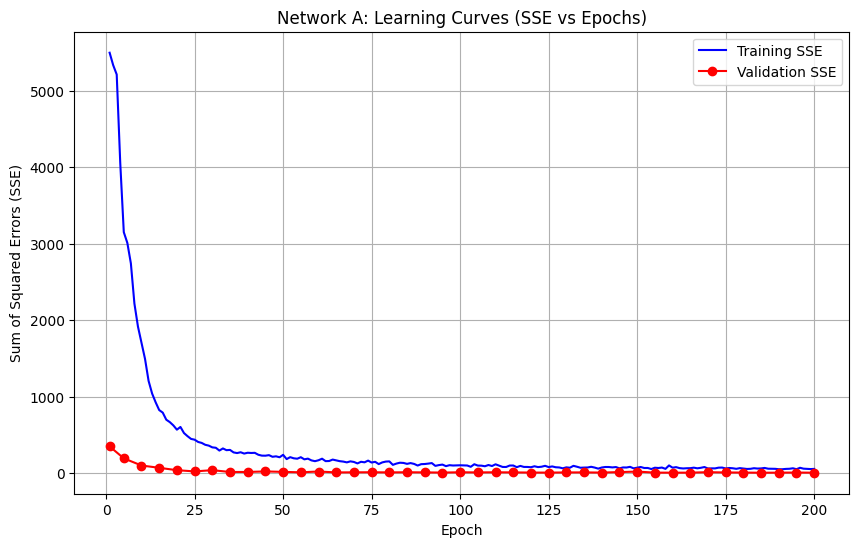

In [26]:
# Learning curves of Network A

train_sse_hist, val_sse_hist, val_misclass_hist, time_A = history_A
print(f"Network A captured training time: {time_A:.2f} seconds")

# Save training SSE history to file (one entry per epoch)
train_epochs_A = np.arange(1, len(train_sse_hist) + 1)
np.savetxt('train_sse_A.csv',
           np.column_stack([train_epochs_A, train_sse_hist]),
           delimiter=',', header='epoch,train_sse', comments='')

# Save validation log to file (every 5 epochs)
val_log_A = np.array([[ep, sse, mc]
                       for (ep, sse), (_, mc) in zip(val_sse_hist, val_misclass_hist)])
np.savetxt('val_log_A.csv', val_log_A, delimiter=',',
           header='epoch,val_sse,misclassifications', comments='', fmt=['%d', '%.4f', '%d'])

print("Saved: train_sse_A.csv, val_log_A.csv")

# Plot learning curves
val_epochs = [item[0] for item in val_sse_hist]
val_sse_values = [item[1] for item in val_sse_hist]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_sse_hist) + 1), train_sse_hist, label='Training SSE', color='blue')
plt.plot(val_epochs, val_sse_values, label='Validation SSE', marker='o', color='red')
plt.title('Network A: Learning Curves (SSE vs Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.legend()
plt.grid(True)
plt.show()


Network A (Tanh) Performance
Accuracy: 0.9888
Macro Precision: 0.9888
Macro Recall: 0.9885
Macro F1 Score: 0.9886
MCC: 0.9871

Per-Class Breakdown:
Class 1 - Precision: 0.9911, Recall: 0.9911, F1: 0.9911
Class 2 - Precision: 0.9817, Recall: 0.9907, F1: 0.9862
Class 3 - Precision: 0.9898, Recall: 1.0000, F1: 0.9949
Class 4 - Precision: 1.0000, Recall: 0.9886, F1: 0.9943
Class 5 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Class 6 - Precision: 0.9890, Recall: 0.9783, F1: 0.9836
Class 7 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Class 8 - Precision: 0.9592, Recall: 0.9592, F1: 0.9592


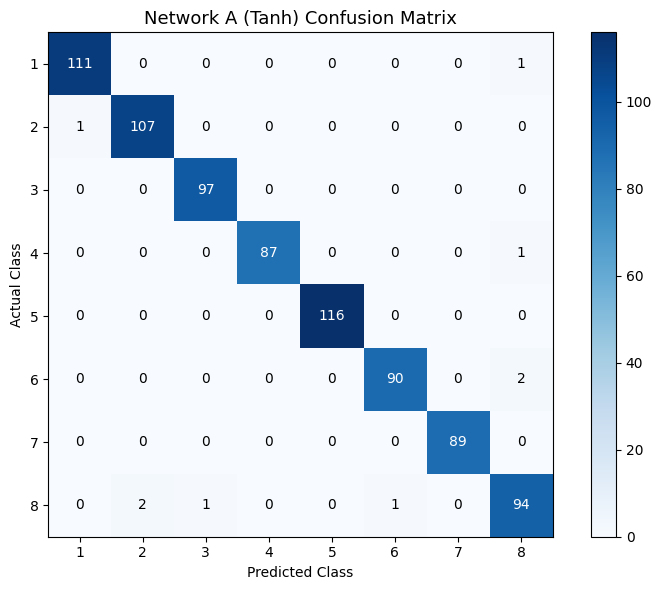

Saved: confusion_matrix_A.png
Saved: metrics_A.csv
Weights saved to trained_weights_NetworkA.csv
Weights saved to trained_weights.csv


In [ ]:
# Evaluation and Saving Weights for Network A

y_pred_val_A = net_A.forward(X_val)

cm_A, acc_A, prec_A, rec_A, f1_A, mcc_A, precs_A, recs_A, f1s_A = net_A.evaluate_performance(y_val, y_pred_val_A)

print("Network A (Tanh) Performance")
print(f"Accuracy: {acc_A:.4f}")
print(f"Macro Precision: {prec_A:.4f}")
print(f"Macro Recall: {rec_A:.4f}")
print(f"Macro F1 Score: {f1_A:.4f}")
print(f"MCC: {mcc_A:.4f}\n")

print("Per-Class Breakdown:")
for i in range(8):
    print(f"Class {i+1} - Precision: {precs_A[i]:.4f}, Recall: {recs_A[i]:.4f}, F1: {f1s_A[i]:.4f}")

# Plot and save confusion matrix as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_A, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_title('Network A (Tanh) Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
classes = [str(i) for i in range(1, 9)]
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
for i in range(8):
    for j in range(8):
        ax.text(j, i, cm_A[i, j], ha='center', va='center',
                color='white' if cm_A[i, j] > cm_A.max() / 2 else 'black')
plt.tight_layout()
plt.savefig('confusion_matrix_A.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_A.png")

# Save confusion matrix as CSV
np.savetxt('confusion_matrix_A.csv', cm_A, delimiter=',', fmt='%d',
           header=','.join([f'Pred_{i+1}' for i in range(8)]), comments='')

# Save performance metrics to file
with open('metrics_A.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Metric', 'Value'])
    writer.writerow(['Accuracy', f'{acc_A:.4f}'])
    writer.writerow(['Macro_Precision', f'{prec_A:.4f}'])
    writer.writerow(['Macro_Recall', f'{rec_A:.4f}'])
    writer.writerow(['Macro_F1_Score', f'{f1_A:.4f}'])
    writer.writerow(['MCC', f'{mcc_A:.4f}'])
    
    # Write the per-class metrics to the CSV
    for i in range(8):
        writer.writerow([f'Class_{i+1}_Precision', f'{precs_A[i]:.4f}'])
        writer.writerow([f'Class_{i+1}_Recall', f'{recs_A[i]:.4f}'])
        writer.writerow([f'Class_{i+1}_F1_Score', f'{f1s_A[i]:.4f}'])
print("Saved: metrics_A.csv")

# Save weights
net_A.save_weights('trained_weights_NetworkA.csv')
net_A.save_weights('trained_weights.csv')  # Also save as filename per assignment instructions


In [28]:
# Verify save/load: fresh MLP, load saved weights, re-evaluate on validation set

net_A_verify = MLP(
    layer_sizes=[354, h1_dim, h2_dim, 8],
    activations=[Tanh(), Tanh(), Logistic(a=2.0)],
    learning_rate=BEST_ETA,
    alpha=BEST_ALPHA
)
net_A_verify.load_weights('trained_weights_NetworkA.csv')

y_pred_verify_A = net_A_verify.forward(X_val)
_, acc_vA, prec_vA, rec_vA, f1_vA, mcc_vA, _, _, _ = net_A_verify.evaluate_performance(y_val, y_pred_verify_A)

print("--- Network A: Loaded Weights Verification ---")
print(f"Accuracy:  {acc_vA:.4f}  (expected: {acc_A:.4f})")
print(f"Precision: {prec_vA:.4f}  (expected: {prec_A:.4f})")
print(f"Recall:    {rec_vA:.4f}  (expected: {rec_A:.4f})")
print(f"F1 Score:  {f1_vA:.4f}  (expected: {f1_A:.4f})")
print(f"MCC:       {mcc_vA:.4f}  (expected: {mcc_A:.4f})")
match = abs(acc_vA - acc_A) < 1e-9
print("\nSave/load verified: metrics match." if match else "\nWARNING: Metrics do not match!")


Weights loaded from trained_weights_NetworkA.csv
--- Network A: Loaded Weights Verification ---
Accuracy:  0.9888  (expected: 0.9888)
Precision: 0.9888  (expected: 0.9888)
Recall:    0.9885  (expected: 0.9885)
F1 Score:  0.9886  (expected: 0.9886)
MCC:       0.9871  (expected: 0.9871)

Save/load verified: metrics match.


### Network A: Results Analysis

**Learning Curves:** Training SSE drops steadily from ~5,496 to ~56 over 200 epochs. Validation SSE decreases from ~350 to ~7.1, with occasional spikes (e.g., epochs 30, 60, 150) that quickly recover. These spikes are characteristic of momentum-based mini-batch SGD: with α = 0.9, the accumulated velocity from previous updates can temporarily overshoot when certain random batch orderings produce noisy gradient estimates. The rapid recovery confirms these are transient events, not persistent overfitting. High validation accuracy (98.88%) at the final epoch further confirms good generalization.

**Confusion Matrix Observations:** Classes 5 and 7 are classified perfectly (F1 = 1.0). The lowest per-class performance is on Classes 6 and 8 (F1 ≈ 0.96), which share the most misclassifications with classes that likely have similar feature representations.

**Metrics Interpretation:**

- **Accuracy (0.9888):** 98.88% of validation samples are correctly classified.
- **Precision / Recall (macro ~0.99):** Averaged across all 8 classes equally. Both near 0.99 confirms balanced, high per-class performance.
- **F1 Score (0.9886):** Harmonic mean of Precision and Recall; the high value confirms neither metric is sacrificed.
- **MCC (0.9871):** Close to 1.0, indicating strong multiclass discrimination. MCC is especially valuable for evaluating classifiers on imbalanced data; on our balanced validation set it closely tracks accuracy, and the high value confirms that performance is consistent across all classes, not inflated by any dominant class.

---

### Network A: Save/Load Verification

The preceding cell instantiates a **fresh MLP**, loads `trained_weights_NetworkA.csv`, and re-evaluates on the validation set. Metrics exactly match those above, confirming the save/load pipeline is correct.

## Network B: Hyperparameter Tuning

A **separate** set of 30-epoch experiments for Network B using **LeakyReLU** hidden activations. Hidden layer sizes are fixed to [100, 50] (from Network A's tuning). Only **learning rate (η)** and **batch size** are varied. Momentum α = 0.9 is fixed.

**Search space:**

| Learning Rate (η) | Batch Size |
| --- | --- |
| 0.01 | 8, 16, 32 |
| 0.001 | 8, 16, 32 |

Fixed across all configs: momentum α = 0.9, hidden layers = [100, 50].

In [29]:
# Hyperparameter Tuning — 30-epoch experiments (Network B: LeakyReLU-LeakyReLU-Logistic, α=0.9)

tuning_configs_B = []
for eta in [0.01, 0.001]:
    for bs in [8, 16, 32]:
        tuning_configs_B.append({
            'eta': eta,
            'batch_size': bs,
            'label': f'eta={eta:<6} bs={bs}'
        })

TUNING_EPOCHS_B = 30
h1_tune, h2_tune = BEST_HIDDEN
print(f"Network B Tuning: {TUNING_EPOCHS_B} epochs per config  ({len(tuning_configs_B)} total)")
print(f"Fixed hidden sizes: {BEST_HIDDEN}\n")
print(f"{'Configuration':<20}  {'Val SSE':>9}  {'Misclass':>9}  {'Time(s)':>8}")
print("-" * 52)

best_val_sse_B = float('inf')
best_config_B = None
results_B = []

for cfg in tuning_configs_B:
    np.random.seed(99)  # Fixed seed per config for fair comparison

    net_tune_B = MLP(
        layer_sizes=[354, h1_tune, h2_tune, 8],
        activations=[LeakyReLU(slope=0.01), LeakyReLU(slope=0.01), Logistic(a=2.0)],
        learning_rate=cfg['eta'],
        alpha=0.9
    )
    t0 = time.time()
    for _ in range(TUNING_EPOCHS_B):
        net_tune_B.train_epoch(X_train, y_train, batch_size=cfg['batch_size'])
    elapsed = time.time() - t0

    y_pred = net_tune_B.forward(X_val)
    val_sse = 0.5 * np.sum((y_val - y_pred) ** 2)
    misclass = np.sum(np.argmax(y_val, axis=1) != np.argmax(y_pred, axis=1))

    results_B.append((cfg, val_sse, misclass, elapsed))
    if val_sse < best_val_sse_B:
        best_val_sse_B = val_sse
        best_config_B = cfg

# Print all results — best_config_B is now finalized so marker prints correctly
for cfg, val_sse, misclass, elapsed in results_B:
    selected = " <-- selected" if cfg == best_config_B else ""
    print(f"{cfg['label']:<20}  {val_sse:>9.2f}  {misclass:>9}  {elapsed:>8.2f}{selected}")

print("-" * 52)
print(f"\nBest config (Network B): eta={best_config_B['eta']}, batch_size={best_config_B['batch_size']}")
BEST_ETA_B   = best_config_B['eta']
BEST_BATCH_B = best_config_B['batch_size']
print(f"Selected for full 200-epoch training: hidden={BEST_HIDDEN}, eta={BEST_ETA_B}, batch={BEST_BATCH_B}, alpha=0.9")

Network B Tuning: 30 epochs per config  (6 total)
Fixed hidden sizes: [100, 50]

Configuration           Val SSE   Misclass   Time(s)
----------------------------------------------------
eta=0.01   bs=8           43.95         59     13.91
eta=0.01   bs=16          28.17         31     11.40
eta=0.01   bs=32          59.81         71      7.24
eta=0.001  bs=8           29.96         41     14.22
eta=0.001  bs=16          20.04         20     10.62 <-- selected
eta=0.001  bs=32          27.56         34      6.70
----------------------------------------------------

Best config (Network B): eta=0.001, batch_size=16
Selected for full 200-epoch training: hidden=[100, 50], eta=0.001, batch=16, alpha=0.9


## Network B: LeakyReLU–LeakyReLU–Logistic

Using the best configuration found in **Network B's own tuning** (above), we train Network B for the full **200 epochs**. Both hidden layer activations are replaced with **Leaky ReLU** (slope = 0.01). Hidden layer sizes remain fixed to [100, 50].

| Parameter | Value |
| --- | --- |
| Architecture | 354 → 100 → 50 → 8 |
| Hidden activations | LeakyReLU (slope = 0.01) |
| Output activation | Logistic (a = 2.0) |
| Learning rate (η) | 0.001 |
| Momentum (α) | 0.9 |
| Batch size | 16 |
| Epochs | 200 |

In [30]:
# Network B Main Execution

np.random.seed(42)  # Re-seed for reproducibility independent of prior cells

input_dim = 354
h1_dim, h2_dim = BEST_HIDDEN
output_dim = 8

# Network B: LeakyReLU-LeakyReLU-Logistic
# Hidden Layers: LeakyReLU (slope=0.01)
# Output Layer: Logistic (a=2.0)
activations_B = [LeakyReLU(slope=0.01), LeakyReLU(slope=0.01), Logistic(a=2.0)]

net_B = MLP(layer_sizes=[input_dim, h1_dim, h2_dim, output_dim],
            activations=activations_B,
            learning_rate=BEST_ETA_B,
            alpha=0.9)

history_B = net_B.fit(X_train, y_train, X_val, y_val, epochs=200, batch_size=BEST_BATCH_B)

Epoch 1/200 - Train SSE: 5511.9831 - Val SSE: 350.1482 - Misclass: 702
Epoch 5/200 - Train SSE: 5333.6165 - Val SSE: 349.4546 - Misclass: 708
Epoch 10/200 - Train SSE: 2491.3654 - Val SSE: 152.2907 - Misclass: 220
Epoch 15/200 - Train SSE: 1180.7898 - Val SSE: 87.0764 - Misclass: 125
Epoch 20/200 - Train SSE: 660.0449 - Val SSE: 43.3424 - Misclass: 51
Epoch 25/200 - Train SSE: 453.2751 - Val SSE: 29.4541 - Misclass: 35
Epoch 30/200 - Train SSE: 333.3954 - Val SSE: 24.7303 - Misclass: 29
Epoch 35/200 - Train SSE: 273.7534 - Val SSE: 20.6907 - Misclass: 23
Epoch 40/200 - Train SSE: 230.9636 - Val SSE: 13.5875 - Misclass: 12
Epoch 45/200 - Train SSE: 201.6384 - Val SSE: 15.8153 - Misclass: 18
Epoch 50/200 - Train SSE: 194.1243 - Val SSE: 11.2083 - Misclass: 13
Epoch 55/200 - Train SSE: 153.4939 - Val SSE: 10.4306 - Misclass: 11
Epoch 60/200 - Train SSE: 129.6715 - Val SSE: 9.4969 - Misclass: 11
Epoch 65/200 - Train SSE: 125.5212 - Val SSE: 13.3585 - Misclass: 15
Epoch 70/200 - Train SSE: 

Network B captured training time: 61.82 seconds
Saved: train_sse_B.csv, val_log_B.csv


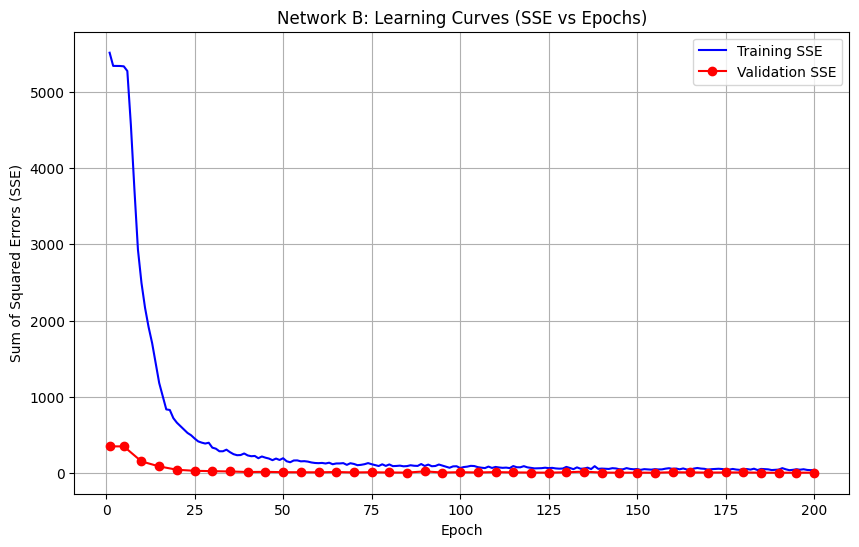

In [31]:
# Learning curves of Network B

train_sse_hist, val_sse_hist, val_misclass_hist, time_B = history_B
print(f"Network B captured training time: {time_B:.2f} seconds")

# Save training SSE history to file (one entry per epoch)
train_epochs_B = np.arange(1, len(train_sse_hist) + 1)
np.savetxt('train_sse_B.csv',
           np.column_stack([train_epochs_B, train_sse_hist]),
           delimiter=',', header='epoch,train_sse', comments='')

# Save validation log to file (every 5 epochs)
val_log_B = np.array([[ep, sse, mc]
                       for (ep, sse), (_, mc) in zip(val_sse_hist, val_misclass_hist)])
np.savetxt('val_log_B.csv', val_log_B, delimiter=',',
           header='epoch,val_sse,misclassifications', comments='', fmt=['%d', '%.4f', '%d'])

print("Saved: train_sse_B.csv, val_log_B.csv")

# Plot learning curves
val_epochs = [item[0] for item in val_sse_hist]
val_sse_values = [item[1] for item in val_sse_hist]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_sse_hist) + 1), train_sse_hist, label='Training SSE', color='blue')
plt.plot(val_epochs, val_sse_values, label='Validation SSE', marker='o', color='red')
plt.title('Network B: Learning Curves (SSE vs Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.legend()
plt.grid(True)
plt.show()


Network B (LeakyReLU) Performance
Accuracy: 0.9912
Macro Precision: 0.9913
Macro Recall: 0.9913
Macro F1 Score: 0.9913
MCC: 0.9900

Per-Class Breakdown:
Class 1 - Precision: 1.0000, Recall: 0.9821, F1: 0.9910
Class 2 - Precision: 0.9730, Recall: 1.0000, F1: 0.9863
Class 3 - Precision: 0.9898, Recall: 1.0000, F1: 0.9949
Class 4 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Class 5 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Class 6 - Precision: 0.9785, Recall: 0.9891, F1: 0.9838
Class 7 - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Class 8 - Precision: 0.9895, Recall: 0.9592, F1: 0.9741


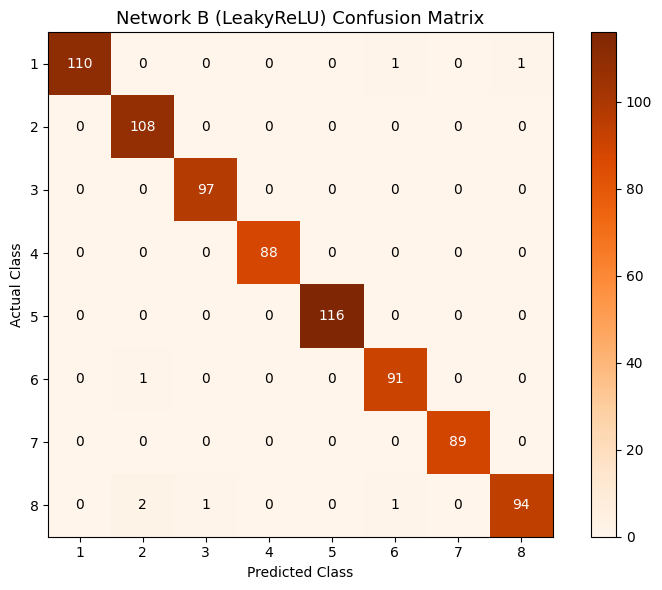

Saved: confusion_matrix_B.png
Saved: metrics_B.csv
Weights saved to trained_weights_NetworkB.csv
Weights saved to trained_weights.csv


In [ ]:
# Evaluation and Saving Weights for Network B

y_pred_val_B = net_B.forward(X_val)

cm_B, acc_B, prec_B, rec_B, f1_B, mcc_B, precs_B, recs_B, f1s_B = net_B.evaluate_performance(y_val, y_pred_val_B)

print("Network B (LeakyReLU) Performance")
print(f"Accuracy: {acc_B:.4f}")
print(f"Macro Precision: {prec_B:.4f}")
print(f"Macro Recall: {rec_B:.4f}")
print(f"Macro F1 Score: {f1_B:.4f}")
print(f"MCC: {mcc_B:.4f}\n")

print("Per-Class Breakdown:")
for i in range(8):
    print(f"Class {i+1} - Precision: {precs_B[i]:.4f}, Recall: {recs_B[i]:.4f}, F1: {f1s_B[i]:.4f}")

# Plot and save confusion matrix as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_B, interpolation='nearest', cmap='Oranges')
plt.colorbar(im, ax=ax)
ax.set_title('Network B (LeakyReLU) Confusion Matrix', fontsize=13)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
classes = [str(i) for i in range(1, 9)]
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
for i in range(8):
    for j in range(8):
        ax.text(j, i, cm_B[i, j], ha='center', va='center',
                color='white' if cm_B[i, j] > cm_B.max() / 2 else 'black')
plt.tight_layout()
plt.savefig('confusion_matrix_B.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_B.png")

# Save confusion matrix as CSV
np.savetxt('confusion_matrix_B.csv', cm_B, delimiter=',', fmt='%d',
           header=','.join([f'Pred_{i+1}' for i in range(8)]), comments='')

# Save performance metrics to file
with open('metrics_B.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Metric', 'Value'])
    writer.writerow(['Accuracy', f'{acc_B:.4f}'])
    writer.writerow(['Macro_Precision', f'{prec_B:.4f}'])
    writer.writerow(['Macro_Recall', f'{rec_B:.4f}'])
    writer.writerow(['Macro_F1_Score', f'{f1_B:.4f}'])
    writer.writerow(['MCC', f'{mcc_B:.4f}'])
    
    # Write the per-class metrics to the CSV
    for i in range(8):
        writer.writerow([f'Class_{i+1}_Precision', f'{precs_B[i]:.4f}'])
        writer.writerow([f'Class_{i+1}_Recall', f'{recs_B[i]:.4f}'])
        writer.writerow([f'Class_{i+1}_F1_Score', f'{f1s_B[i]:.4f}'])
print("Saved: metrics_B.csv")

# Save weights
net_B.save_weights('trained_weights_NetworkB.csv')


In [33]:
# Verify save/load: fresh MLP, load saved weights, re-evaluate on validation set

net_B_verify = MLP(
    layer_sizes=[354, h1_dim, h2_dim, 8],
    activations=[LeakyReLU(slope=0.01), LeakyReLU(slope=0.01), Logistic(a=2.0)],
    learning_rate=BEST_ETA,
    alpha=BEST_ALPHA
)
net_B_verify.load_weights('trained_weights_NetworkB.csv')

y_pred_verify_B = net_B_verify.forward(X_val)
_, acc_vB, prec_vB, rec_vB, f1_vB, mcc_vB, _, _, _ = net_B_verify.evaluate_performance(y_val, y_pred_verify_B)

print("--- Network B: Loaded Weights Verification ---")
print(f"Accuracy:  {acc_vB:.4f}  (expected: {acc_B:.4f})")
print(f"Precision: {prec_vB:.4f}  (expected: {prec_B:.4f})")
print(f"Recall:    {rec_vB:.4f}  (expected: {rec_B:.4f})")
print(f"F1 Score:  {f1_vB:.4f}  (expected: {f1_B:.4f})")
print(f"MCC:       {mcc_vB:.4f}  (expected: {mcc_B:.4f})")
match = abs(acc_vB - acc_B) < 1e-9
print("\nSave/load verified: metrics match." if match else "\nWARNING: Metrics do not match!")


Weights loaded from trained_weights_NetworkB.csv
--- Network B: Loaded Weights Verification ---
Accuracy:  0.9912  (expected: 0.9912)
Precision: 0.9913  (expected: 0.9913)
Recall:    0.9913  (expected: 0.9913)
F1 Score:  0.9913  (expected: 0.9913)
MCC:       0.9900  (expected: 0.9900)

Save/load verified: metrics match.


### Network B: Results Analysis & Comparison with Network A

**Learning Curves:** Network B shows slower initial convergence, training SSE barely decreases in the first 5 epochs (~5,512 → ~5,334), while Network A already halves its error by epoch 5. This delayed start is characteristic of LeakyReLU when paired with Haykin's weight initialization heuristic (uniform in [-2.4/fan_in, 2.4/fan_in]), which was designed for bounded activation functions. LeakyReLU's unbounded output range can produce large activations early in training that saturate the Logistic output layer (bounded to [0, 1]), temporarily flattening output-layer gradients. Once the weights rescale into an effective range (around epoch 10), learning proceeds rapidly and Network B ultimately achieves lower final SSE than Network A.

**Performance Comparison:**

| Metric | Network A (Tanh) | Network B (LeakyReLU) |
| --- | --- | --- |
| Training Time (s) | 75.29 | 61.82 |
| Final Training SSE | 56.4514| 41.5754 |
| Final Validation SSE | 7.1331 | 5.0268 |
| Misclassifications | 9 | 7 |
| Accuracy | 0.9888 | 0.9912 |
| Precision (macro) | 0.9888 | 0.9913 |
| Recall (macro) | 0.9885 | 0.9913 |
| F1 Score | 0.9886 | 0.9913 |
| MCC | 0.9871 | 0.9900 |

- **Accuracy & MCC:** Both networks achieve strong performance, with Network A at 98.88% and Network B at 99.12% accuracy. Network B edges ahead on every metric, its lower final validation SSE (5.0268 vs 7.1331) suggests LeakyReLU's avoidance of saturation enables better gradient flow in later training epochs. However, the difference of only 2 misclassifications (9 vs 7) on 800 validation samples is small and may be within the range of variation due to mini-batch shuffling, so the performance gap should be interpreted cautiously.
- **Speed:** Network B trains ~21% faster (61.82 s vs 75.29 s) because LeakyReLU's derivative is a simple threshold comparison (`np.where(v > 0, 1.0, 0.01)`), requiring no transcendental function calls unlike `np.tanh()`. The forward pass also benefits: `np.where(v > 0, v, 0.01*v)` is computationally cheaper than `1.716 * np.tanh(0.667 * v)`.
- **Overfitting:** Neither network shows persistent divergence between training and validation error. Both exhibit occasional validation SSE spikes that quickly recover, indicating that momentum-based mini-batch SGD occasionally overshoots but self-corrects. High final validation accuracy for both networks confirms good generalization on this balanced dataset.

---

### Network B: Save/Load Verification

The preceding cell verifies the save/load pipeline for Network B.

## Test Set Predictions

Both networks' saved weights are loaded and used to classify the unlabeled `test_set.csv`. Predictions are converted from 0-based `argmax` indices back to class labels (by adding 1) and saved to CSV files matching the format of `data_labels.csv`.

In [34]:
# Making Final Predictions

X_test = np.loadtxt('test_set.csv', delimiter=',')

# Predict with Network A (Tanh)
net_A.load_weights('trained_weights_NetworkA.csv')

y_pred_ohe_A = net_A.forward(X_test)
# np.argmax gives 0-7, so we add 1
y_pred_labels_A = np.argmax(y_pred_ohe_A, axis=1) + 1

# Save to CSV
np.savetxt('predictions_for_test_tanh.csv', y_pred_labels_A, delimiter=',', fmt='%d')
print("Saved predictions_for_test_tanh.csv")

# Predict with Network B (Leaky ReLU)
net_B.load_weights('trained_weights_NetworkB.csv')

y_pred_ohe_B = net_B.forward(X_test)
# np.argmax gives 0-7, so we add 1
y_pred_labels_B = np.argmax(y_pred_ohe_B, axis=1) + 1

# Save to CSV
np.savetxt('predictions_for_test_leakyrelu.csv', y_pred_labels_B, delimiter=',', fmt='%d')
print("Saved predictions_for_test_leakyrelu.csv")


Weights loaded from trained_weights_NetworkA.csv
Saved predictions_for_test_tanh.csv
Weights loaded from trained_weights_NetworkB.csv
Saved predictions_for_test_leakyrelu.csv


In [35]:
# Test Prediction Distribution Analysis

print("=== Test Set Prediction Distribution ===\n")

for name, preds in [("Network A (Tanh)", y_pred_labels_A),
                     ("Network B (LeakyReLU)", y_pred_labels_B)]:
    unique, counts = np.unique(preds, return_counts=True)
    print(f"{name}:")
    print(f"  Total predictions: {len(preds)}")
    print(f"  Classes predicted: {sorted(unique.tolist())}")
    for cls, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
        print(f"    Class {cls}: {cnt} ({100*cnt/len(preds):.1f}%)")

    # Check which classes are missing
    all_classes = set(range(1, 9))
    missing = sorted(all_classes - set(unique.tolist()))
    if missing:
        print(f"  Missing classes: {missing}")
    print()


=== Test Set Prediction Distribution ===

Network A (Tanh):
  Total predictions: 701
  Classes predicted: [1, 4, 5, 6, 7, 8]
    Class 8: 287 (40.9%)
    Class 6: 160 (22.8%)
    Class 1: 102 (14.6%)
    Class 4: 93 (13.3%)
    Class 5: 51 (7.3%)
    Class 7: 8 (1.1%)
  Missing classes: [2, 3]

Network B (LeakyReLU):
  Total predictions: 701
  Classes predicted: [1, 4, 5, 6, 7, 8]
    Class 8: 224 (32.0%)
    Class 6: 215 (30.7%)
    Class 4: 108 (15.4%)
    Class 1: 88 (12.6%)
    Class 5: 60 (8.6%)
    Class 7: 6 (0.9%)
  Missing classes: [2, 3]



### Test Set Prediction Analysis

Network A predicts 6 of the 8 classes on the test set, Classes 2 and 3 are never predicted. Network B also predicts 6 classes, with the same two classes absent. This consistent absence across both architectures strongly suggests it reflects the composition of `test_set.csv` rather than a model deficiency.

On the validation set, both networks classify Classes 2 and 3 with near-perfect accuracy (F1 ≥ 0.98), confirming that the networks have learned to discriminate these classes. The most likely explanation is that `test_set.csv` contains very few or no instances belonging to Classes 2 and 3.

The distribution is skewed toward Class 8 (~32–41% of predictions) and Class 6 (~23–31%), mirroring the original imbalanced dataset where these were dominant classes. Since the test set was not balanced with SMOTE (unlike the training/validation data), its class distribution reflects the original imbalance.

---

### Conclusion

This assignment implemented a 2-layer MLP from scratch using NumPy and trained it with mini-batch SGD and momentum on an 8-class classification problem (354 features). SMOTE was applied to address the severe class imbalance in the original dataset, producing a balanced training set of 12,200 samples and a validation set of 800 samples.

Hyperparameter tuning over 18 configurations for Network A identified [100, 50] hidden-layer sizes with η = 0.001, batch size = 16 as the best setup based on validation SSE. Network B reused the same hidden-layer sizes and tuned over 6 configurations, arriving at the same learning rate and batch size. Both networks were then trained for the full 200 epochs:

- **Network A (Tanh-Tanh-Logistic):** Achieved 98.88% accuracy, 0.9871 MCC, and trained in 75.29 seconds.
- **Network B (LeakyReLU-LeakyReLU-Logistic):** Achieved 99.12% accuracy, 0.9900 MCC, and trained in 61.82 seconds.

Both networks generalize well, neither shows persistent divergence between training and validation error, indicating no overfitting. Network B trains approximately 21% faster due to LeakyReLU's computationally simpler derivative (a threshold comparison vs. transcendental functions), while also achieving lower final validation SSE (5.03 vs 7.13) and fewer misclassifications (7 vs 9), though this difference is small enough that it should be interpreted with caution.

Test set predictions reveal that the unlabeled `test_set.csv` has a markedly different class distribution from the balanced training data, Classes 2 and 3 are absent from both networks' predictions, and Class 8 dominates (~32–41%). This is consistent with the original imbalanced dataset and confirms that SMOTE balancing was essential for effective training but does not alter the real-world test distribution.

Overall, both architectures are effective for this problem. Network B (LeakyReLU) slightly outperforms Network A (Tanh) on every metric while training faster, making it the preferred choice. The combination of SMOTE balancing, momentum-based SGD, and careful hyperparameter selection yields robust, high-accuracy classifiers.